# BERT Fine-Tuning and SHAP Visualization for Suicide Classification

In [1]:
!pip install -q kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d nikhileswarkomati/suicide-watch
!unzip suicide-watch.zip
import pandas as pd
df = pd.read_csv('Suicide_Detection.csv')
print(f"Dataset shape: {df.shape}")
print(df.head())

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch
License(s): CC-BY-SA-4.0
Archive:  suicide-watch.zip
  inflating: Suicide_Detection.csv   
Dataset shape: (232074, 3)
   Unnamed: 0                                               text        class
0           2  Ex Wife Threatening SuicideRecently I left my ...      suicide
1           3  Am I weird I don't get affected by compliments...  non-suicide
2           4  Finally 2020 is almost over... So I can never ...  non-suicide
3           8          i need helpjust help me im crying so hard      suicide
4           9  I’m so lostHello, my name is Adam (16) and I’v...      suicide


In [4]:
!pip install -q transformers datasets shap scikit-learn
import pandas as pd
import torch
import shap
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup, get_scheduler
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df = pd.read_csv("Suicide_Detection.csv").dropna()
df['label'] = df['class'].map({'non-suicide': 0, 'suicide': 1})
df_small = df.groupby('label', group_keys=False).apply(lambda x: x.sample(n=5000, random_state=42)).reset_index(drop=True)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_small['text'].tolist(), df_small['label'].tolist(),
    test_size=0.2, stratify=df_small['label'], random_state=42
)

class RedditDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)


tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_dataset = RedditDataset(train_texts, train_labels, tokenizer)
val_dataset = RedditDataset(val_texts, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)


model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
num_training_steps = len(train_loader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

model.train()
for batch in train_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = model(**batch)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    lr_scheduler.step()
    optimizer.zero_grad()


model.eval()
preds, true = [], []
for batch in val_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
    logits = outputs.logits
    preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
    true.extend(batch["labels"].cpu().numpy())

print(classification_report(true, preds, target_names=["non-suicide", "suicide"]))


model.save_pretrained("fine_tuned_bert")
tokenizer.save_pretrained("fine_tuned_bert")




<ipython-input-4-a2e5c59994f6>:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_small = df.groupby('label', group_keys=False).apply(lambda x: x.sample(n=5000, random_state=42)).reset_index(drop=True)
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


              precision    recall  f1-score   support

 non-suicide       0.96      0.97      0.97      1000
     suicide       0.97      0.96      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.96      0.96      2000



('fine_tuned_bert/tokenizer_config.json',
 'fine_tuned_bert/special_tokens_map.json',
 'fine_tuned_bert/vocab.txt',
 'fine_tuned_bert/added_tokens.json',
 'fine_tuned_bert/tokenizer.json')

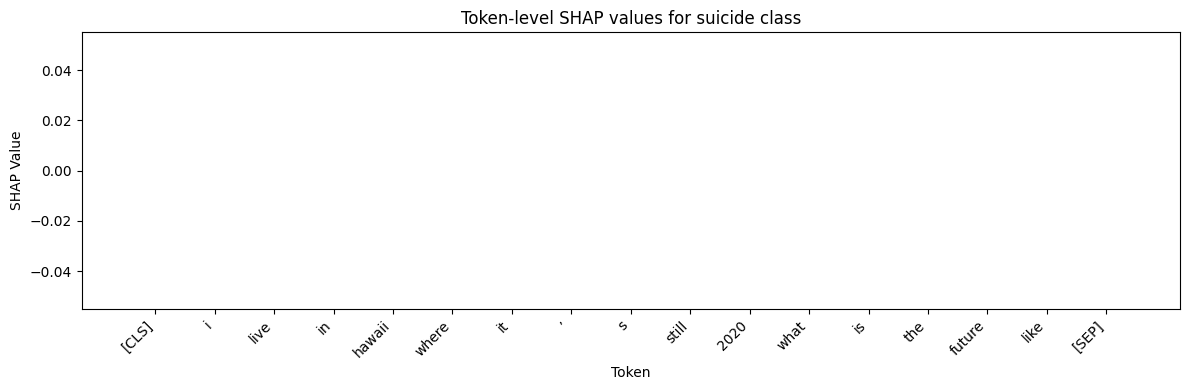

In [5]:
tokenizer = AutoTokenizer.from_pretrained("fine_tuned_bert")
model = AutoModelForSequenceClassification.from_pretrained("fine_tuned_bert").to(device)
model.eval()

sample_text = val_texts[0]
encoding = tokenizer(sample_text, return_tensors="pt", padding=True, truncation=True, max_length=128)
input_ids = encoding["input_ids"].to(device)

def predict_prob(input_ids_np):
    input_ids_tensor = torch.tensor(input_ids_np, dtype=torch.long).to(model.device)
    attention_mask_tensor = (input_ids_tensor != tokenizer.pad_token_id).long()
    with torch.no_grad():
        outputs = model(input_ids=input_ids_tensor, attention_mask=attention_mask_tensor)
    return torch.nn.functional.softmax(outputs.logits, dim=1).cpu().numpy()

input_ids_np = input_ids.cpu().numpy()
explainer = shap.Explainer(predict_prob, input_ids_np)
shap_values = explainer(input_ids_np)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
scores = shap_values.values[0][:len(tokens), 1]

plt.figure(figsize=(12, 4))
plt.bar(tokens, scores)
plt.xticks(rotation=45, ha="right")
plt.title("Token-level SHAP values for suicide class")
plt.ylabel("SHAP Value")
plt.xlabel("Token")
plt.tight_layout()
plt.show()


In [6]:
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=(input_ids != tokenizer.pad_token_id).long())
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
print(f"Prediction probabilities: {probs}")

Prediction probabilities: tensor([[0.9767, 0.0233]], device='cuda:0')


In [7]:
uncertain_examples = []
uncertain_indices = []

val_loader_no_shuffle = DataLoader(val_dataset, batch_size=16, shuffle=False)
with torch.no_grad():
    for i, batch in enumerate(val_loader_no_shuffle):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)

        for j, prob in enumerate(probs):
            if (0.3 < prob[0] < 0.7) or (0.3 < prob[1] < 0.7):
                idx = i * 16 + j
                if idx < len(val_texts):
                    uncertain_examples.append(val_texts[idx])
                    uncertain_indices.append(idx)
                    if len(uncertain_examples) >= 5:
                        break
        if len(uncertain_examples) >= 5:
            break

if uncertain_examples:
    for i, (text, idx) in enumerate(zip(uncertain_examples, uncertain_indices)):
        inputs = tokenizer(text, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=1)

        print(f"Example {i+1} (true label: {val_labels[idx]}):")
        print(f"Prediction: {probs.cpu().numpy()}")
        print(f"Text: {text[:100]}...")
        print("-" * 80)

Example 1 (true label: 1):
Prediction: [[0.02248481 0.97751516]]
Text: guess this is me writing..a little background about me, i’m 17M, from down south in the US, about to...
--------------------------------------------------------------------------------
Example 2 (true label: 0):
Prediction: [[0.4655331  0.53446686]]
Text: I feel like an American I finally mustered the courage to make an appointment with a therapist. Hurr...
--------------------------------------------------------------------------------
Example 3 (true label: 1):
Prediction: [[0.5351156 0.4648844]]
Text: Sometimes I look up at the sky...Sometimes I look up at the sky on those days where the blue peeks o...
--------------------------------------------------------------------------------
Example 4 (true label: 0):
Prediction: [[0.4379741 0.5620259]]
Text: Everyday is the same I wake up. I shower. I walk my dogs. I go to school. I get out of school. I do ...
-------------------------------------------------------------

Analyzing example with true label: 1
Text preview: guess this is me writing..a little background about me, i’m 17M, from down south in the US, about to...
Model prediction: [[0.6551404  0.34485963]]


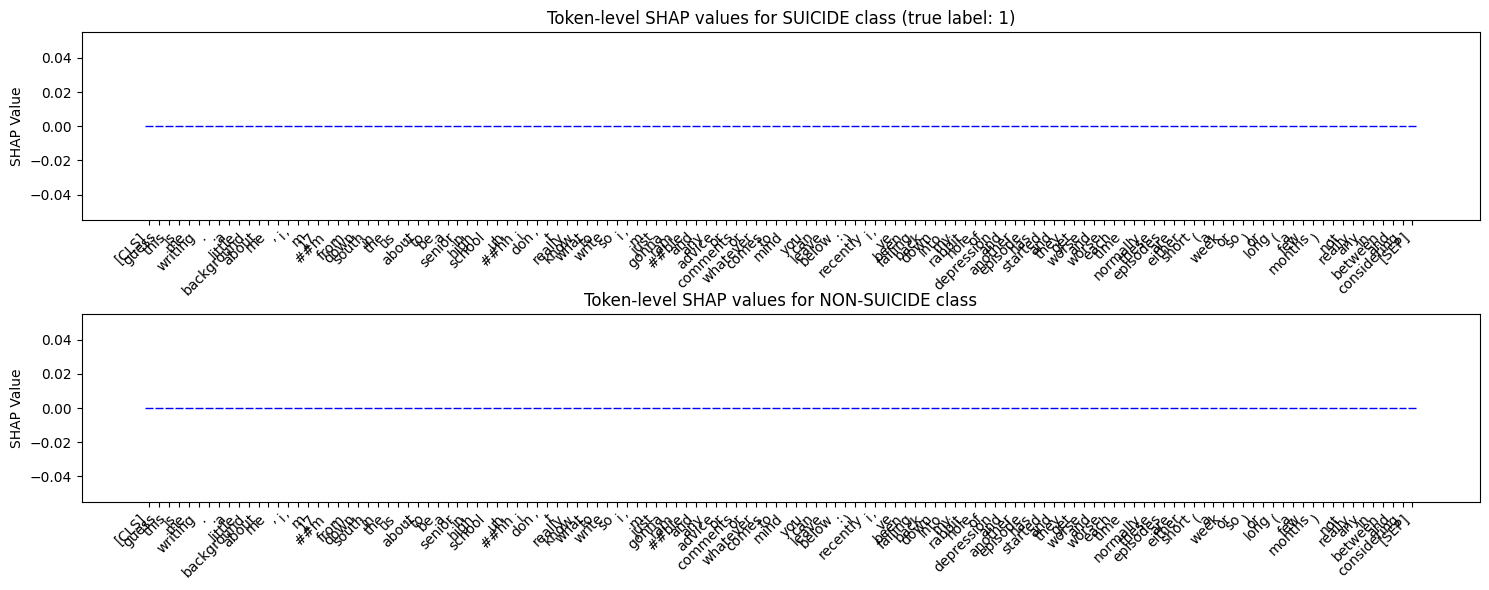

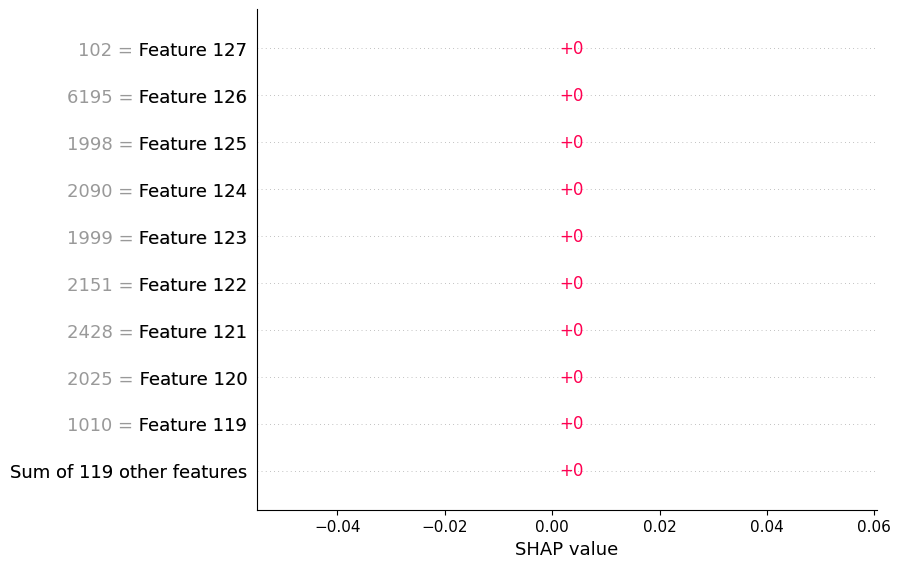

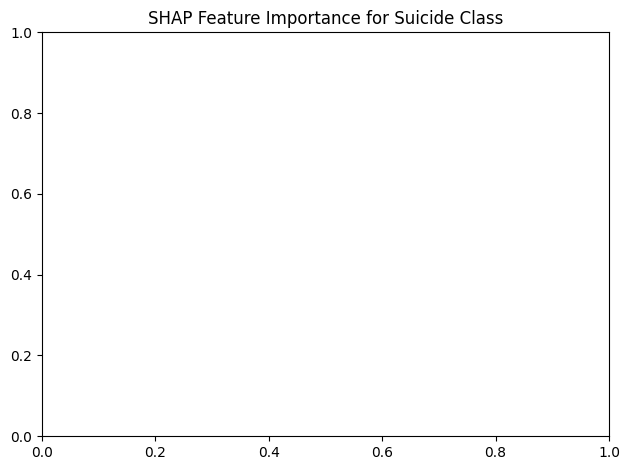

In [10]:
example_index = 0
text_to_analyze = uncertain_examples[example_index]
true_label = val_labels[uncertain_indices[example_index]]

print(f"Analyzing example with true label: {true_label}")
print(f"Text preview: {text_to_analyze[:100]}...")

encoding = tokenizer(text_to_analyze, return_tensors="pt", padding=True, truncation=True, max_length=128)
input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)

with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
print(f"Model prediction: {probs.cpu().numpy()}")

def predict_prob(input_ids_np):
    input_ids_tensor = torch.tensor(input_ids_np, dtype=torch.long).to(device)
    attention_mask_tensor = (input_ids_tensor != tokenizer.pad_token_id).long()
    with torch.no_grad():
        outputs = model(input_ids=input_ids_tensor, attention_mask=attention_mask_tensor)
    return torch.nn.functional.softmax(outputs.logits, dim=1).cpu().numpy()

input_ids_np = input_ids.cpu().numpy()
explainer = shap.Explainer(predict_prob, input_ids_np)
shap_values = explainer(input_ids_np)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
suicide_class_scores = shap_values.values[0][:len(tokens), 1]
non_suicide_class_scores = shap_values.values[0][:len(tokens), 0]

plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
bars1 = plt.bar(range(len(tokens)), suicide_class_scores)
plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
plt.title(f"Token-level SHAP values for SUICIDE class (true label: {true_label})")
plt.ylabel("SHAP Value")
plt.tight_layout()

for i, bar in enumerate(bars1):
    bar.set_color('red' if suicide_class_scores[i] > 0 else 'blue')

plt.subplot(2, 1, 2)
bars2 = plt.bar(range(len(tokens)), non_suicide_class_scores)
plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
plt.title(f"Token-level SHAP values for NON-SUICIDE class")
plt.ylabel("SHAP Value")
plt.tight_layout()

for i, bar in enumerate(bars2):
    bar.set_color('red' if non_suicide_class_scores[i] > 0 else 'blue')

plt.subplots_adjust(hspace=0.5)
plt.show()

plt.figure(figsize=(12, 8))
shap.plots.bar(shap_values[0, :, 1])
plt.title("SHAP Feature Importance for Suicide Class")
plt.tight_layout()
plt.show()


BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


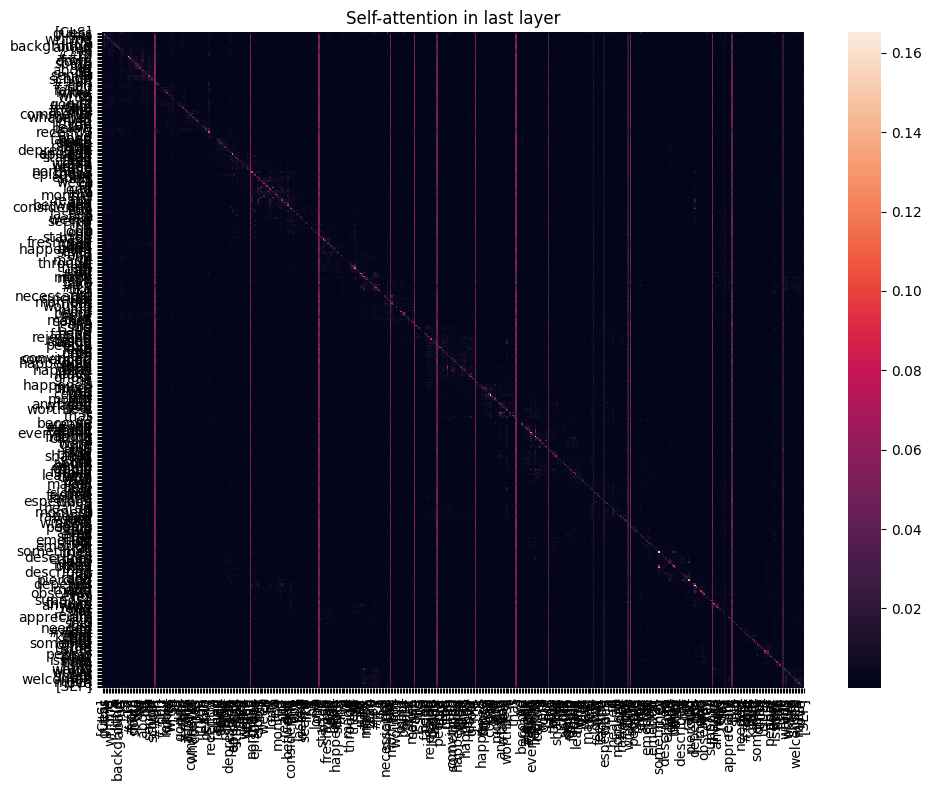

In [12]:
# Visualize attention patterns
input_ids = tokenizer.encode(text_to_analyze, return_tensors="pt").to(device)
attention_mask = (input_ids != tokenizer.pad_token_id).long().to(device)
with torch.no_grad():
    # Get attention weights from the last layer
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
    attentions = outputs.attentions[-1].squeeze(0)  # Get last layer attention

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
attention_scores = attentions.mean(dim=0).cpu().numpy()  # Average across attention heads

plt.figure(figsize=(10, 8))
sns.heatmap(attention_scores, xticklabels=tokens, yticklabels=tokens)
plt.title("Self-attention in last layer")
plt.tight_layout()
plt.show()